In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel(logging.ERROR)

DATA_DIR = r"C:\animals"
BATCH_SIZE = 16
IMG_SIZE = (224, 224)
SEED = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def apply_augmentation(images, labels):
    return data_augmentation(images, training=True), labels

train_ds = train_ds.map(apply_augmentation, num_parallel_calls=AUTOTUNE)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=15, 
    callbacks=callbacks
)

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10, 
    callbacks=callbacks
)

model_save_path = r"C:\Users\emir_\Documents\animal-classifier\animal_model"
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
model.save(model_save_path)

Found 5400 files belonging to 90 classes.
Using 4320 files for training.
Found 5400 files belonging to 90 classes.
Using 1080 files for validation.
Found 5400 files belonging to 90 classes.
Using 1080 files for validation.
Epoch 1/15
Epoch 1/15
270/270 [==============================] - 11s 30ms/step - loss: 2.0353 - accuracy: 0.5398 - val_loss: 0.7079 - val_accuracy: 0.8194
Epoch 2/15
Epoch 2/15
270/270 [==============================] - 6s 23ms/step - loss: 0.6886 - accuracy: 0.8190 - val_loss: 0.5589 - val_accuracy: 0.8370
Epoch 3/15
Epoch 3/15
270/270 [==============================] - 10s 38ms/step - loss: 0.4866 - accuracy: 0.8637 - val_loss: 0.4888 - val_accuracy: 0.8602
Epoch 4/15
Epoch 4/15
270/270 [==============================] - 11s 40ms/step - loss: 0.3595 - accuracy: 0.8979 - val_loss: 0.4656 - val_accuracy: 0.8611
Epoch 5/15
Epoch 5/15
270/270 [==============================] - 11s 40ms/step - loss: 0.3140 - accuracy: 0.9130 - val_loss: 0.4292 - val_accuracy: 0.8769
Epo

In [3]:
import requests
from PIL import Image
import matplotlib.pyplot as plt
from io import BytesIO

def predict_clean(url):
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers, timeout=10)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img_resized = img.resize(IMG_SIZE)
    img_array = np.array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    predicted_class = class_names[predicted_class_idx]
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title('Test Resmi')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    top_5_indices = np.argsort(predictions[0])[-5:][::-1]
    top_5_probs = predictions[0][top_5_indices]
    top_5_names = [class_names[i] for i in top_5_indices]
    
    colors = ['red' if i == 0 else 'blue' for i in range(5)]
    plt.barh(range(5), top_5_probs, color=colors)
    plt.yticks(range(5), top_5_names)
    plt.xlabel('Tahmin Olasılığı')
    plt.title('Temiz Model')
    plt.xlim(0, 1)
    
    for i, (prob, name) in enumerate(zip(top_5_probs, top_5_names)):
        plt.text(prob + 0.01, i, f'{prob:.2%}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return predicted_class, confidence

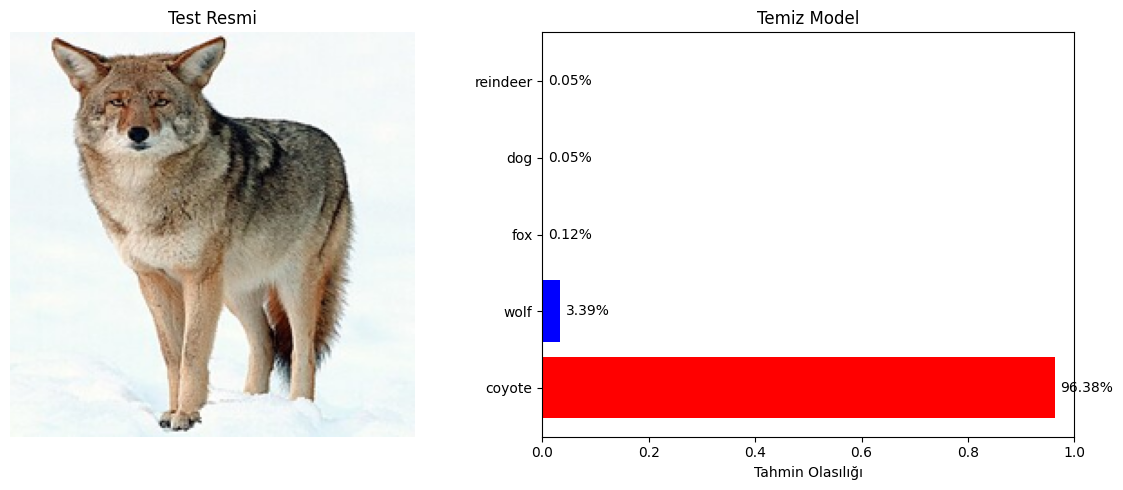

('coyote', 0.9637831)

In [6]:
url="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9c/2009-Coyote-Yosemite.jpg/250px-2009-Coyote-Yosemite.jpg"
predict_clean(url)